# PINN pro 2D lineární elastostatiku na kruhové oblasti

Cílem je aproximovat posunutí
$\mathbf u=(u_1,u_2)$ na kruhové oblasti o poloměru $R$:

$$
\Omega
=
\left\{
(x,y)\in\mathbb R^2:
x^2+y^2<R^2
\right\}.
$$

Přesné řešení je

$$
\mathbf u(x,y)
=
a
\begin{bmatrix}
x^2-y^2\\
2xy
\end{bmatrix}.
$$

Použité parametry jsou

$$

R=2
\qquad
a=0,15.
\qquad 
E=1,00,
\qquad
\nu=\frac14,
\qquad
\lambda=\mu=\frac25.
$$

## Silná forma

Stejná jako v `PINN_elastostatika_2D.ipynb`.


## Parametrizace kruhové hranice

Kružnici o poloměru $R$ se středem v počátku parametrizujeme
pomocí úhlu $\alpha$:

$$
\mathbf x(\alpha)
=
\begin{bmatrix}
x(\alpha)\\
y(\alpha)
\end{bmatrix}
=
\begin{bmatrix}
R\cos\alpha\\
R\sin\alpha
\end{bmatrix},
\qquad
\alpha\in[0,2\pi).
$$




Vnější jednotková normála kružnice je

$$
\mathbf n(\alpha)
=
\frac{1}{R}
\begin{bmatrix}
x(\alpha)\\
y(\alpha)
\end{bmatrix}
=
\begin{bmatrix}
\cos\alpha\\
\sin\alpha
\end{bmatrix}.
$$



## Smíšené okrajové podmínky

Hranici rozdělíme na horní Dirichletovu a dolní Neumannovu
půlkružnici:

$$
\Gamma_D
=
\left\{
(R\cos\alpha,R\sin\alpha):
\alpha\in[0,\pi]
\right\},
$$

$$
\Gamma_N
=
\left\{
(R\cos\alpha,R\sin\alpha):
\alpha\in(\pi,2\pi)
\right\}.
$$

### Dirichletova podmínka

Na $\Gamma_D$ předepisujeme přesné posunutí:

$$
\mathbf u(R\cos\alpha,R\sin\alpha)
=
a
\begin{bmatrix}
(R\cos\alpha)^2-(R\sin\alpha)^2\\
2(R\cos\alpha)(R\sin\alpha)
\end{bmatrix}.
$$

Po vytknutí $R^2$ dostaneme

$$
\mathbf u(R\cos\alpha,R\sin\alpha)
=
aR^2
\begin{bmatrix}
\cos^2\alpha-\sin^2\alpha\\
2\cos\alpha\sin\alpha
\end{bmatrix}.
$$

Pomocí goniometrických vztahů lze podmínku zapsat jako

$$
\boxed{
\mathbf u(R\cos\alpha,R\sin\alpha)
=
aR^2
\begin{bmatrix}
\cos(2\alpha)\\
\sin(2\alpha)
\end{bmatrix},
\qquad
\alpha\in[0,\pi].
}
$$

### Neumannova podmínka

Na $\Gamma_N$ předepisujeme trakci

$$
\boldsymbol{\sigma}\mathbf n=\mathbf t.
$$

Na kružnici dosadíme

$$
x=R\cos\alpha,
\qquad
y=R\sin\alpha.
$$

Tenzor napětí na kružnici je proto

$$
\boldsymbol{\sigma}(R\cos\alpha,R\sin\alpha)
=
4a(\lambda+\mu)R\cos\alpha\,\mathbf I.
$$

Trakce je

$$
\begin{aligned}
\mathbf t(R\cos\alpha,R\sin\alpha)
&=
\boldsymbol{\sigma}(R\cos\alpha,R\sin\alpha)
\mathbf n(\alpha)
\\
&=
4a(\lambda+\mu)R\cos\alpha\,
\mathbf I
\begin{bmatrix}
\cos\alpha\\
\sin\alpha
\end{bmatrix}.
\end{aligned}
$$

Po vynásobení dostaneme

$$
\boxed{
\mathbf t(R\cos\alpha,R\sin\alpha)
=
4a(\lambda+\mu)R
\begin{bmatrix}
\cos^2\alpha\\
\cos\alpha\sin\alpha
\end{bmatrix},
\qquad
\alpha\in(\pi,2\pi).
}
$$


## 1. Import knihoven

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Nastavení parametrů

- `USE_DATA = True`: k fyzikální a okrajové loss se přidají známé hodnoty posunutí.
- `USE_DATA = False`: čistá PINN bez supervizovaných dat.
- Oblastí je kruh o poloměru `RADIUS = 2.0`.
- Posledních 100 epoch používá L-BFGS, předchozí epochy Adam.


In [2]:
USE_DATA = False
E = 1.0
NU = 1.0 / 4.0
LAMBDA = 2.0 / 5.0
MU = 2.0 / 5.0
AMPLITUDE = 0.15 
RADIUS = 2.0

N_PDE_TRAIN = 2000
N_PDE_VALIDATION = 1000
N_PDE_TEST = 2000
N_BOUNDARY_PER_ARC = 100

N_DATA_TRAIN = 50
N_DATA_VALIDATION = 20
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

print(f"E z Lameho konstant:  {E_FROM_LAME:.6f}")
print(f"nu z Lameho konstant: {NU_FROM_LAME:.6f}")


E z Lameho konstant:  1.000000
nu z Lameho konstant: 0.250000


## 3. Přesné řešení, napětí a objemová síla

In [3]:
def exact_solution(xy):
    """Presne vektorove posunuti [u1, u2]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]

    u1 = AMPLITUDE * (x**2 - y**2)
    u2 = 2.0 * AMPLITUDE * x * y

    return torch.cat((u1, u2), dim=1)


def body_force(xy):
    """b = -div(sigma) pro zvolene presne reseni."""
    b1 = -4.0 * AMPLITUDE * (LAMBDA + MU) * torch.ones_like(xy[:, 0:1])
    b2 = torch.zeros_like(xy[:, 1:2])

    return torch.cat((b1, b2), dim=1)


def exact_stress(xy):
    """Presne slozky sigma_xx, sigma_yy, sigma_xy."""
    x = xy[:, 0:1]

    normal_stress = 4.0 * AMPLITUDE * (LAMBDA + MU) * x
    shear_stress = torch.zeros_like(x)

    return normal_stress, normal_stress, shear_stress


def exact_traction(xy, normals):
    """Presna trakce t = sigma*n."""
    sigma_xx, sigma_yy, sigma_xy = exact_stress(xy)

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny

    return torch.cat((traction_x, traction_y), dim=1)


## 4. Neuronová síť

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 2),
        )

    def forward(self, xy):
        return self.net(xy)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Trénovací, validační, testovací a okrajové body

Validační body jsou pevné, nezávislé a optimalizátor je nepoužívá.


In [5]:
def sample_points_in_disk(n_points, generator):
    """Rovnomerne vzorkuje body v plose disku."""
    random_radius = torch.rand(n_points, 1, generator=generator)
    random_angle = torch.rand(n_points, 1, generator=generator)
    radius = RADIUS * torch.sqrt(random_radius)
    angle = 2.0 * torch.pi * random_angle
    return torch.cat((radius * torch.cos(angle), radius * torch.sin(angle)), dim=1)

pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = sample_points_in_disk(N_PDE_TRAIN, pde_train_generator)
xy_pde_train.requires_grad_(True)

pde_validation_generator = torch.Generator().manual_seed(SEED + 10)
xy_pde_validation = sample_points_in_disk(N_PDE_VALIDATION, pde_validation_generator)
xy_pde_validation.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = sample_points_in_disk(N_PDE_TEST, pde_test_generator)
xy_pde_test.requires_grad_(True)

alpha_dirichlet = torch.linspace(0.0, torch.pi, N_BOUNDARY_PER_ARC).view(-1, 1)
xy_dirichlet = RADIUS * torch.cat((torch.cos(alpha_dirichlet), torch.sin(alpha_dirichlet)), dim=1)
u_dirichlet = exact_solution(xy_dirichlet)

boundary_index = torch.arange(N_BOUNDARY_PER_ARC, dtype=torch.get_default_dtype()).view(-1, 1)
alpha_neumann = torch.pi + (boundary_index + 0.5) * torch.pi / N_BOUNDARY_PER_ARC
xy_neumann = RADIUS * torch.cat((torch.cos(alpha_neumann), torch.sin(alpha_neumann)), dim=1)
normals_neumann = xy_neumann / RADIUS
traction_neumann = exact_traction(xy_neumann, normals_neumann).detach()
xy_neumann.requires_grad_(True)

if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = sample_points_in_disk(N_DATA_TRAIN, data_train_generator)
    u_data_train = exact_solution(xy_data_train)

    data_validation_generator = torch.Generator().manual_seed(SEED + 11)
    xy_data_validation = sample_points_in_disk(N_DATA_VALIDATION, data_validation_generator)
    u_data_validation = exact_solution(xy_data_validation)

    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = sample_points_in_disk(N_DATA_TEST, data_test_generator)
    u_data_test = exact_solution(xy_data_test)


## 6. PDE reziduum a ztrátová funkce

Fyzikální reziduum PINN je definováno jako

$$
\mathbf{r}_{\theta}(x,y)
=
\nabla \cdot \boldsymbol{\sigma}(\mathbf{u}_{\theta})
+\mathbf{b}.
$$

PDE ztrátová funkce je

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{2N_c}
\sum_{i=1}^{N_c}
\left\|
\mathbf{r}_{\theta}(x_i,y_i)
\right\|_2^2.
$$

Celková ztrátová funkce je

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\mathcal{L}_{\mathrm{D}}
+
\mathcal{L}_{\mathrm{N}}
+
\mathcal{L}_{\mathrm{data}}.
$$

Dirichletova loss na horní půlkružnici je

$$
\mathcal{L}_{\mathrm{D}}
=
\frac{1}{2N_D}
\sum_{i=1}^{N_D}
\left\|
\mathbf{u}_{\theta}(\cos\alpha_i,\sin\alpha_i)
-
a
\begin{bmatrix}
\cos(2\alpha_i)\\
\sin(2\alpha_i)
\end{bmatrix}
\right\|_2^2,
\qquad \alpha_i\in[0,\pi].
$$

Neumannova loss na dolní půlkružnici je

$$
\mathcal{L}_{\mathrm{N}}
=
\frac{1}{2N_N}
\sum_{i=1}^{N_N}
\left\|
\boldsymbol{\sigma}
\left(\mathbf{u}_{\theta}(\cos\alpha_i,\sin\alpha_i)\right)
\begin{bmatrix}
\cos\alpha_i\\
\sin\alpha_i
\end{bmatrix}
-
0.16
\begin{bmatrix}
\cos^2\alpha_i\\
\cos\alpha_i\sin\alpha_i
\end{bmatrix}
\right\|_2^2,
\qquad \alpha_i\in(\pi,2\pi).
$$

Pro `USE_DATA = False` platí

$$
\mathcal{L}_{\mathrm{data}}=0.
$$


In [6]:
def stress_components(xy):
    """Vrati sigma_xx, sigma_yy, sigma_xy pro predikci site."""
    u = model(xy)
    u1 = u[:, 0:1]
    u2 = u[:, 1:2]

    grad_u1 = torch.autograd.grad(
        u1,
        xy,
        grad_outputs=torch.ones_like(u1),
        create_graph=True,
        retain_graph=True,
    )[0]

    grad_u2 = torch.autograd.grad(
        u2,
        xy,
        grad_outputs=torch.ones_like(u2),
        create_graph=True,
        retain_graph=True,
    )[0]

    du1_dx = grad_u1[:, 0:1]
    du1_dy = grad_u1[:, 1:2]
    du2_dx = grad_u2[:, 0:1]
    du2_dy = grad_u2[:, 1:2]

    eps_xx = du1_dx
    eps_yy = du2_dy
    eps_xy = 0.5 * (du1_dy + du2_dx)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy

    return sigma_xx, sigma_yy, sigma_xy


def pde_residual(xy, training=True):
    """Vrati dve slozky rezidua div(sigma) + b."""
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy)

    grad_sigma_xx = torch.autograd.grad(
        sigma_xx,
        xy,
        grad_outputs=torch.ones_like(sigma_xx),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_yy = torch.autograd.grad(
        sigma_yy,
        xy,
        grad_outputs=torch.ones_like(sigma_yy),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_xy = torch.autograd.grad(
        sigma_xy,
        xy,
        grad_outputs=torch.ones_like(sigma_xy),
        create_graph=training,
        retain_graph=True,
    )[0]

    b = body_force(xy)

    residual_1 = (
        grad_sigma_xx[:, 0:1]
        + grad_sigma_xy[:, 1:2]
        + b[:, 0:1]
    )

    residual_2 = (
        grad_sigma_xy[:, 0:1]
        + grad_sigma_yy[:, 1:2]
        + b[:, 1:2]
    )

    return torch.cat((residual_1, residual_2), dim=1)


def compute_losses():
    # PDE loss.
    residual = pde_residual(xy_pde_train, training=True)
    loss_pde = torch.mean(residual**2)

    # Dirichletova loss na horni pulkruznici.
    dirichlet_prediction = model(xy_dirichlet)
    loss_dirichlet = torch.mean(
        (dirichlet_prediction - u_dirichlet) ** 2
    )

    # Neumannova loss na dolni pulkruznici.
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy_neumann)

    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    traction_prediction = torch.cat((traction_x, traction_y), dim=1)

    loss_neumann = torch.mean(
        (traction_prediction - traction_neumann) ** 2
    )

    loss_bc = loss_dirichlet + loss_neumann

    # Volitelna datova loss.
    if USE_DATA:
        data_prediction = model(xy_data_train)
        loss_data = torch.mean((data_prediction - u_data_train) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = loss_pde + loss_bc + loss_data

    return (
        loss,
        loss_pde,
        loss_bc,
        loss_data,
    )


def compute_validation_losses():
    residual = pde_residual(xy_pde_validation, training=False).detach()
    loss_validation_pde = torch.mean(residual**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(xy_data_validation) - u_data_validation)**2) if USE_DATA else loss_validation_pde.new_tensor(0.0)
    loss_validation = loss_validation_pde + loss_validation_data
    return loss_validation, loss_validation_pde, loss_validation_data


## 7. Trénování, validace a výběr nejlepší epochy


In [7]:
loss_history, pde_loss_history, bc_loss_history, data_loss_history = [], [], [], []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None

def clone_model_state():
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_data_loss, best_epoch, best_model_state
    validation, validation_pde, validation_data = compute_validation_losses()
    values = validation.item(), validation_pde.item(), validation_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_validation_pde_loss, best_validation_data_loss = values
        best_epoch = epoch
        best_model_state = clone_model_state()
    return values[0]


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode="min", factor=0.5, patience=200)
for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    xy_pde_train.grad = None
    xy_neumann.grad = None
    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss.item())
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 500 == 0:
        print(f"Adam | epocha {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | BC={loss_bc.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e}")

print(f"Prepinam z Adam na full-batch L-BFGS v epose {ADAM_EPOCHS}.")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch
    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        xy_neumann.grad = None
        loss = compute_losses()[0]
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f"L-BFGS | epocha {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | BC={loss_bc.item():.6e} | data={loss_data.item():.6e} | validation={validation_value:.6e}")

last_model_state = clone_model_state()
model.load_state_dict(best_model_state)
model.eval()
print(f"Nejlepsi epocha: {best_epoch}")
print(f"Nejmensi validacni loss: {best_validation_loss:.6e}")


Adam | epocha     0 | loss=5.597479e-01 | PDE=1.145249e-01 | BC=4.452229e-01 | data=0.000000e+00 | validation=1.141220e-01
Adam | epocha   500 | loss=9.086997e-04 | PDE=4.203675e-04 | BC=4.883322e-04 | data=0.000000e+00 | validation=4.213767e-04
Adam | epocha  1000 | loss=1.333456e-04 | PDE=1.111158e-04 | BC=2.222973e-05 | data=0.000000e+00 | validation=1.190783e-04
Adam | epocha  1500 | loss=1.015573e-04 | PDE=5.695701e-05 | BC=4.460027e-05 | data=0.000000e+00 | validation=6.087572e-05
Prepinam z Adam na full-batch L-BFGS v epose 1900.
L-BFGS | epocha  1900 | loss=4.314534e-05 | PDE=3.581289e-05 | BC=7.332453e-06 | data=0.000000e+00 | validation=3.802529e-05
L-BFGS | epocha  1950 | loss=1.354826e-06 | PDE=1.247736e-06 | BC=1.070901e-07 | data=0.000000e+00 | validation=1.244170e-06
L-BFGS | epocha  1999 | loss=9.483242e-07 | PDE=8.520116e-07 | BC=9.631258e-08 | data=0.000000e+00 | validation=8.899736e-07
Nejlepsi epocha: 1999
Nejmensi validacni loss: 8.899736e-07


## 8. Testování obnoveného nejlepšího modelu


In [8]:
model.eval()
xy_pde_test.grad = None
residual_test = pde_residual(xy_pde_test, training=False)
pde_test_mse = torch.mean(residual_test**2).detach().item()

with torch.no_grad():
    u_test_prediction = model(xy_pde_test)
    u_test_exact = exact_solution(xy_pde_test)
    ss_res = torch.sum((u_test_prediction - u_test_exact)**2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact))**2)
    r2_test = (1.0 - ss_res / ss_tot).item()
    relative_l2_test = (torch.linalg.vector_norm(u_test_prediction - u_test_exact) / torch.linalg.vector_norm(u_test_exact)).item()

metrics = {"best_epoch": best_epoch, "best_validation_loss": best_validation_loss, "best_validation_PDE_MSE": best_validation_pde_loss, "best_validation_data_MSE": best_validation_data_loss, "R2_collocation_test": r2_test, "relative_L2_collocation_test": relative_l2_test, "PDE_test_MSE": pde_test_mse}

print("=" * 60)
print("TESTOVACI VYSLEDKY OBNOVENEHO NEJLEPSIHO MODELU")
print("=" * 60)
print(f"Nejlepsi epocha:                         {best_epoch}")
print(f"R2 na kolokacnich testovacich bodech:   {r2_test:.8f}")
print(f"Relativni L2 chyba:                      {relative_l2_test:.6e}")
print(f"MSE PDE rezidua:                         {pde_test_mse:.6e}")
print("=" * 60)
metrics


TESTOVACI VYSLEDKY OBNOVENEHO NEJLEPSIHO MODELU
Nejlepsi epocha:                         1999
R2 na kolokacnich testovacich bodech:   0.99999374
Relativni L2 chyba:                      2.498261e-03
MSE PDE rezidua:                         9.138923e-07


{'best_epoch': 1999,
 'best_validation_loss': 8.899736485545873e-07,
 'best_validation_PDE_MSE': 8.899736485545873e-07,
 'best_validation_data_MSE': 0.0,
 'R2_collocation_test': 0.9999937415122986,
 'relative_L2_collocation_test': 0.0024982609320431948,
 'PDE_test_MSE': 9.138922791862569e-07}

## 9. Vizualizační funkce

Grafy zobrazují rozdělení bodů, přesné řešení, nejlepší a poslední epochu, normalizovanou absolutní chybu, PDE reziduum a oddělené trénovací a validační loss.


In [9]:
def make_grid(n=201, requires_grad=False):
    values = torch.linspace(-RADIUS, RADIUS, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    mask = (X**2 + Y**2 <= RADIUS**2).numpy()
    if requires_grad:
        xy.requires_grad_(True)
    return X.numpy(), Y.numpy(), xy, mask

def add_domain_outline(axis):
    axis.add_patch(plt.Circle((0.0, 0.0), RADIUS, fill=False, color="black", linewidth=1.0))


def prediction_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        prediction = model(xy).detach().clone()
    model.load_state_dict(current_state)
    return prediction

def plot_points():
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    if ncols == 1:
        axes = [axes]
    axes[0].scatter(xy_pde_train[:, 0].detach().numpy(), xy_pde_train[:, 1].detach().numpy(), s=10, alpha=0.5, label=f"PDE train ({len(xy_pde_train)})")
    axes[0].scatter(xy_pde_validation[:, 0].detach().numpy(), xy_pde_validation[:, 1].detach().numpy(), s=9, marker="s", alpha=0.35, label=f"PDE validation ({len(xy_pde_validation)})")
    axes[0].scatter(xy_pde_test[:, 0].detach().numpy(), xy_pde_test[:, 1].detach().numpy(), s=8, marker="x", alpha=0.25, label=f"PDE test ({len(xy_pde_test)})")
    axes[0].scatter(xy_dirichlet[:, 0].detach().numpy(), xy_dirichlet[:, 1].detach().numpy(), s=14, color="tab:red", label="Dirichlet")
    axes[0].scatter(xy_neumann[:, 0].detach().numpy(), xy_neumann[:, 1].detach().numpy(), s=14, color="black", label="Neumann")
    axes[0].set(title="Fyzikalni a okrajove body", xlabel="x", ylabel="y", xlim=(-1.1 * RADIUS, 1.1 * RADIUS), ylim=(-1.1 * RADIUS, 1.1 * RADIUS))
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()
    add_domain_outline(axes[0])
    if USE_DATA:
        axes[1].scatter(xy_data_train[:, 0].numpy(), xy_data_train[:, 1].numpy(), s=20, label=f"data train ({len(xy_data_train)})")
        axes[1].scatter(xy_data_validation[:, 0].numpy(), xy_data_validation[:, 1].numpy(), s=16, marker="s", color="tab:green", label=f"data validation ({len(xy_data_validation)})")
        axes[1].scatter(xy_data_test[:, 0].numpy(), xy_data_test[:, 1].numpy(), s=16, marker="x", color="tab:orange", label=f"data test ({len(xy_data_test)})")
        axes[1].set(title="Supervizovana data", xlabel="x", ylabel="y", xlim=(-1.1 * RADIUS, 1.1 * RADIUS), ylim=(-1.1 * RADIUS, 1.1 * RADIUS))
        axes[1].set_aspect("equal")
        axes[1].legend()
        axes[1].grid()
        add_domain_outline(axes[1])
    fig.tight_layout()
    plt.savefig("pinn_circle_points.pdf", bbox_inches="tight")
    plt.show()

def plot_displacement(n=201):
    X, Y, xy, mask = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_solution(xy)
    best_tensor = prediction_from_state(best_model_state, xy)
    last_tensor = prediction_from_state(last_model_state, xy)
    eps = torch.finfo(exact_tensor.dtype).eps
    scales = torch.amax(torch.abs(exact_tensor[torch.from_numpy(mask.reshape(-1))]), dim=0, keepdim=True).clamp_min(eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact = exact_tensor.numpy().reshape(n, n, 2)
    best = best_tensor.numpy().reshape(n, n, 2)
    last = last_tensor.numpy().reshape(n, n, 2)
    error = error_tensor.numpy().reshape(n, n, 2)
    fig, axes = plt.subplots(2, 4, figsize=(19, 9))
    for component in range(2):

        exact_field = np.ma.masked_where(~mask, exact[:, :, component])
        best_field = np.ma.masked_where(~mask, best[:, :, component])
        last_field = np.ma.masked_where(~mask, last[:, :, component])
        error_field = np.ma.masked_where(~mask, error[:, :, component])

        limit = max(np.max(np.abs(exact_field)), np.max(np.abs(best_field)), np.max(np.abs(last_field)))
        images = [
            axes[component, 0].contourf(X, Y, exact_field, levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[component, 1].contourf(X, Y, best_field, levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[component, 2].contourf(X, Y, last_field, levels=40, cmap="coolwarm", vmin=-limit, vmax=limit),
            axes[component, 3].contourf(X, Y, error_field, levels=40, cmap="viridis")]
        titles = [f"Presne u{component + 1}", f"Nejlepsi epocha u{component + 1}", f"Posledni epocha u{component + 1}", f"Relativni absolutni chyba u{component + 1}"]
        for axis, image, title in zip(axes[component], images, titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            add_domain_outline(axis)
            fig.colorbar(image, ax=axis)
    fig.tight_layout()
    plt.savefig("pinn_circle_displacement.pdf", bbox_inches="tight")
    plt.show()


def plot_deformed_domain(scale=1.0, n_circles=6, n_rays=12, n_points=181):
    fig, ax = plt.subplots(figsize=(8, 8))
    angle_values = torch.linspace(0.0, 2.0 * torch.pi, n_points)
    radius_values = torch.linspace(0.0, RADIUS, n_points)
    circle_radii = torch.linspace(RADIUS / n_circles, RADIUS, n_circles)
    ray_angles = torch.arange(n_rays) * (2.0 * torch.pi / n_rays)
    lines = [torch.stack((radius * torch.cos(angle_values), radius * torch.sin(angle_values)), dim=1) for radius in circle_radii]
    lines += [torch.stack((radius_values * torch.cos(angle), radius_values * torch.sin(angle)), dim=1) for angle in ray_angles]
    first_line = True
    for line in lines:
        with torch.no_grad():
            exact_deformed = line + scale * exact_solution(line)
            pinn_deformed = line + scale * model(line)
        ax.plot(line[:, 0].numpy(), line[:, 1].numpy(), color="gray", linestyle=":", alpha=0.4, label="puvodni" if first_line else None)
        ax.plot(exact_deformed[:, 0].numpy(), exact_deformed[:, 1].numpy(), "r--", alpha=0.8, label="presna deformace" if first_line else None)
        ax.plot(pinn_deformed[:, 0].numpy(), pinn_deformed[:, 1].numpy(), color="tab:blue", alpha=0.8, label="nejlepsi PINN" if first_line else None)
        first_line = False
    ax.set(title=f"Deformovana kruhova oblast, meritko = {scale}", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("pinn_circle_deformed.pdf", bbox_inches="tight")
    plt.show()


def plot_pde_residual(n=201):
    X, Y, xy, mask = make_grid(n, requires_grad=True)
    residual = pde_residual(xy, training=False).detach().numpy().reshape(n, n, 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for component in range(2):
        value = np.ma.masked_where(~mask, residual[:, :, component])
        image = axes[component].contourf(X, Y, value, levels=40, cmap="coolwarm")
        axes[component].set(title=f"PDE reziduum r{component + 1}", xlabel="x", ylabel="y")
        axes[component].set_aspect("equal")
        add_domain_outline(axes[component])
        fig.colorbar(image, ax=axes[component])
    fig.tight_layout()
    plt.savefig("pinn_circle_residual.pdf", bbox_inches="tight")
    plt.show()

def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(loss_history, label="celkova")
    axes[0].plot(pde_loss_history, label="PDE")
    axes[0].plot(bc_loss_history, label="okrajove podminky")
    if USE_DATA:
        axes[0].plot(data_loss_history, label="data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="prechod na L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"nejlepsi epocha ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epocha", ylabel="loss", title="Trenovaci loss")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(validation_loss_history, label="kombinovana validace")
    axes[1].plot(validation_pde_loss_history, label="validacni PDE")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, label="validacni data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="prechod na L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"nejlepsi epocha ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epocha", ylabel="loss", title="Validacni loss")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("pinn_circle_losses.pdf", bbox_inches="tight")
    plt.show()


## 10. Vizualizace

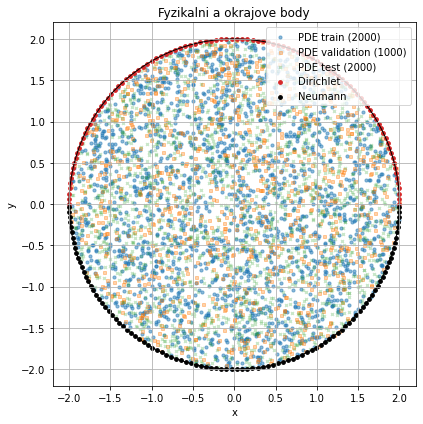

In [10]:
plot_points()


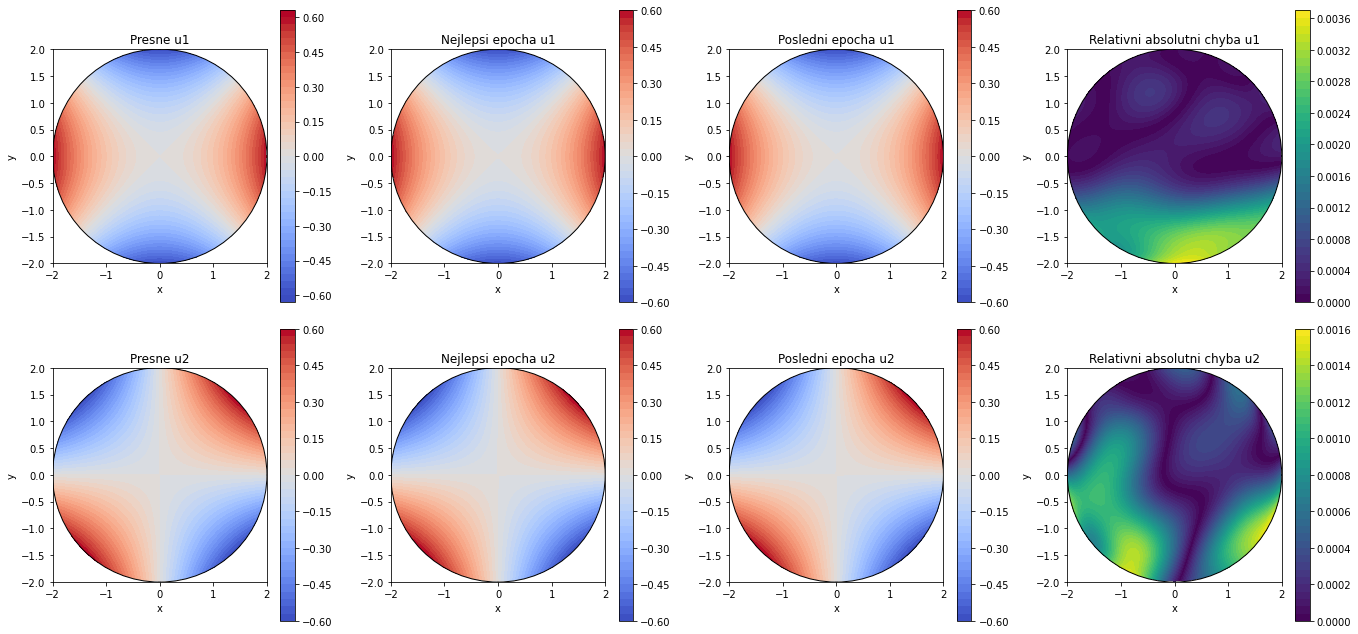

In [11]:
plot_displacement()


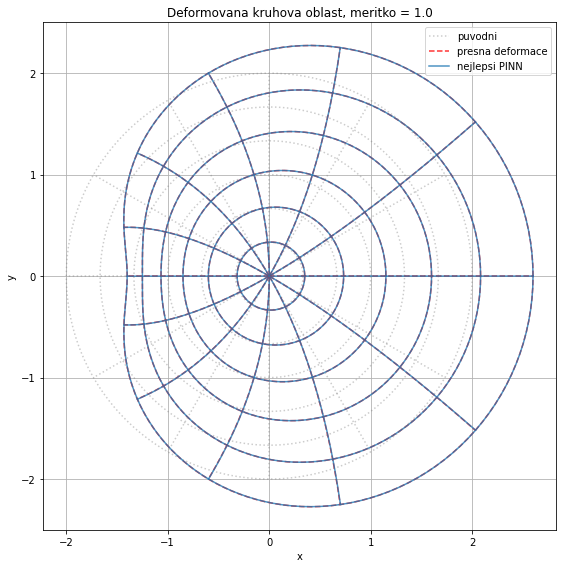

In [12]:
plot_deformed_domain(scale=1.0)


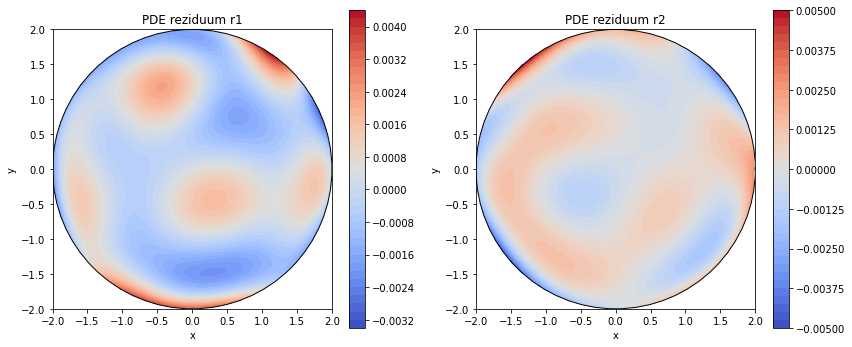

In [13]:
plot_pde_residual()


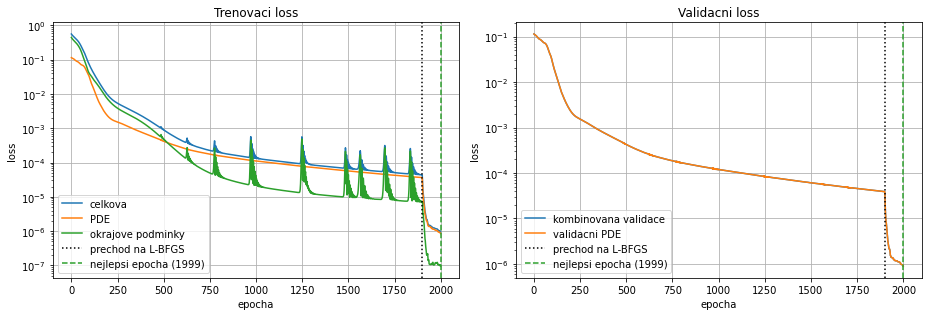

In [14]:
plot_loss()
